# Code

In [1]:
import heapq
import time
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)
%matplotlib inline

print("Setup complete. Ready to explore BFS, DFS, and A* search.")


Setup complete. Ready to explore BFS, DFS, and A* search.


,item,value
0,Rows,8
1,Columns,8
2,Open cells,46
3,Blocked cells,18
4,Start,"(0, 0)"
5,Goal,"(7, 7)"


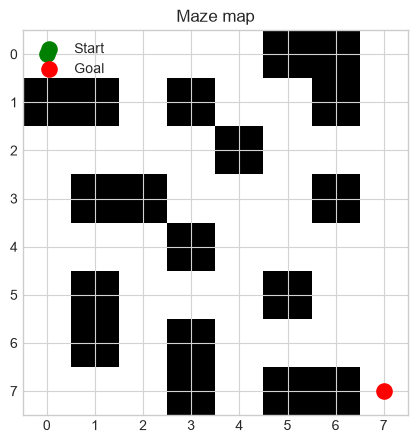

In [2]:
maze = np.array([
    [0, 0, 0, 0, 0, 1, 1, 0],
    [1, 1, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 1, 1, 0],
])

start = (0, 0)
goal = (7, 7)

maze_info = pd.DataFrame({
    "item": ["Rows", "Columns", "Open cells", "Blocked cells", "Start", "Goal"],
    "value": [
        maze.shape[0],
        maze.shape[1],
        int((maze == 0).sum()),
        int((maze == 1).sum()),
        str(start),
        str(goal),
    ],
})
display(maze_info)

plt.figure(figsize=(5, 5))
plt.imshow(maze, cmap="gray_r")
plt.scatter(start[1], start[0], color="green", s=120, label="Start")
plt.scatter(goal[1], goal[0], color="red", s=120, label="Goal")
plt.xticks(range(maze.shape[1]))
plt.yticks(range(maze.shape[0]))
plt.grid(color="lightgray")
plt.title("Maze map")
plt.legend(loc="upper left")
plt.show()


In [3]:
def in_bounds(position, grid):
    row, col = position
    return 0 <= row < grid.shape[0] and 0 <= col < grid.shape[1]

def is_open(position, grid):
    row, col = position
    return grid[row, col] == 0

def neighbors(position, grid):
    row, col = position
    candidates = [
        (row - 1, col),
        (row + 1, col),
        (row, col - 1),
        (row, col + 1),
    ]
    return [
        candidate
        for candidate in candidates
        if in_bounds(candidate, grid) and is_open(candidate, grid)
    ]

def reconstruct_path(parents, end_node):
    path = [end_node]
    while path[-1] in parents:
        path.append(parents[path[-1]])
    path.reverse()
    return path

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

print("Helper functions are ready.")
print("Neighbors of start:", neighbors(start, maze))
print("Manhattan distance from start to goal:", manhattan(start, goal))


Helper functions are ready.
Neighbors of start: [(0, 1)]
Manhattan distance from start to goal: 14


In [4]:
def bfs(grid, start_node, goal_node):
    queue = deque([start_node])
    parents = {}
    visited = {start_node}
    expanded_order = []

    while queue:
        current = queue.popleft()
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in neighbors(current, grid):
            if neighbor not in visited:
                visited.add(neighbor)
                parents[neighbor] = current
                queue.append(neighbor)

    return None, expanded_order

print("BFS function created.")


BFS function created.


In [5]:
def dfs(grid, start_node, goal_node):
    stack = [start_node]
    parents = {}
    visited = {start_node}
    expanded_order = []

    while stack:
        current = stack.pop()
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in reversed(neighbors(current, grid)):
            if neighbor not in visited:
                visited.add(neighbor)
                parents[neighbor] = current
                stack.append(neighbor)

    return None, expanded_order

print("DFS function created.")


DFS function created.


In [6]:
def a_star(grid, start_node, goal_node):
    open_heap = [(manhattan(start_node, goal_node), 0, start_node)]
    parents = {}
    g_score = {start_node: 0}
    closed = set()
    expanded_order = []

    while open_heap:
        _, current_cost, current = heapq.heappop(open_heap)

        if current in closed:
            continue

        closed.add(current)
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in neighbors(current, grid):
            new_cost = current_cost + 1

            if new_cost < g_score.get(neighbor, float("inf")):
                g_score[neighbor] = new_cost
                parents[neighbor] = current
                priority = new_cost + manhattan(neighbor, goal_node)
                heapq.heappush(open_heap, (priority, new_cost, neighbor))

    return None, expanded_order

print("A* function created.")


A* function created.


In [7]:
algorithms = {
    "BFS": bfs,
    "DFS": dfs,
    "A*": a_star,
}

def run_algorithm(name, algorithm):
    start_time = time.perf_counter()
    path, expanded_order = algorithm(maze, start, goal)
    elapsed = time.perf_counter() - start_time

    return {
        "algorithm": name,
        "path": path,
        "expanded_order": expanded_order,
        "path_length": len(path) - 1 if path else None,
        "expanded_nodes": len(expanded_order),
        "time_ms": elapsed * 1000,
    }

results = [run_algorithm(name, algorithm) for name, algorithm in algorithms.items()]

for result in results:
    print("{0}: path length = {1}, expanded nodes = {2}".format(
        result["algorithm"],
        result["path_length"],
        result["expanded_nodes"],
    ))


BFS: path length = 14, expanded nodes = 46
DFS: path length = 28, expanded nodes = 36
A*: path length = 14, expanded nodes = 30


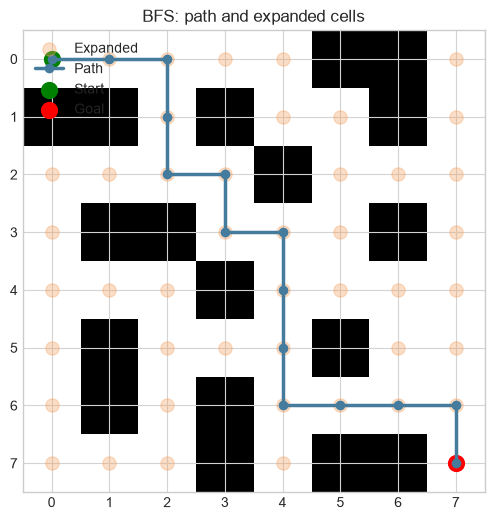

Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (3, 3), (3, 4), (4, 4), (5, 4), (6, 4), (6, 5), (6, 6), (6, 7), (7, 7)]


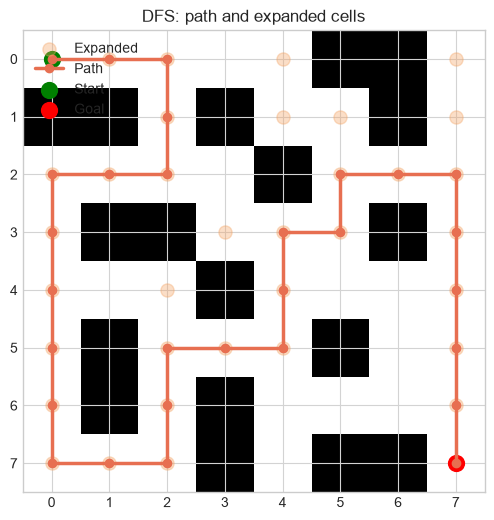

Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (7, 1), (7, 2), (6, 2), (5, 2), (5, 3), (5, 4), (4, 4), (3, 4), (3, 5), (2, 5), (2, 6), (2, 7), (3, 7), (4, 7), (5, 7), (6, 7), (7, 7)]


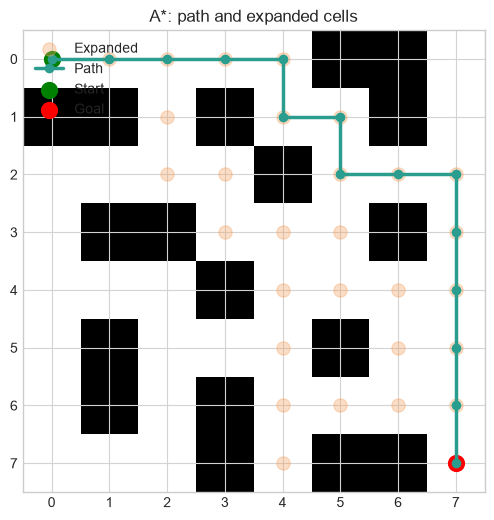

Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (1, 5), (2, 5), (2, 6), (2, 7), (3, 7), (4, 7), (5, 7), (6, 7), (7, 7)]


In [8]:
colors = {
    "BFS": "#457b9d",
    "DFS": "#e76f51",
    "A*": "#2a9d8f",
}

def plot_search_result(algorithm_name="A*"):
    result = next(item for item in results if item["algorithm"] == algorithm_name)
    path = result["path"]
    expanded_order = result["expanded_order"]

    plt.figure(figsize=(6, 6))
    plt.imshow(maze, cmap="gray_r")

    if expanded_order:
        expanded_rows = [position[0] for position in expanded_order]
        expanded_cols = [position[1] for position in expanded_order]
        plt.scatter(expanded_cols, expanded_rows, color="#f4a261", alpha=0.35, s=90, label="Expanded")

    if path:
        path_rows = [position[0] for position in path]
        path_cols = [position[1] for position in path]
        plt.plot(path_cols, path_rows, marker="o", color=colors[algorithm_name], linewidth=2.5, label="Path")

    plt.scatter(start[1], start[0], color="green", s=130, label="Start")
    plt.scatter(goal[1], goal[0], color="red", s=130, label="Goal")
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(color="lightgray")
    plt.title(f"{algorithm_name}: path and expanded cells")
    plt.legend(loc="upper left")
    plt.show()

    print("Path:", path)

for name in algorithms:
    plot_search_result(name)
